In [1]:
from dataset import get_dataloader
import matplotlib.pyplot as plt

mkdir -p failed for path /home/jovyan/.cache/matplotlib: [Errno 13] Permission denied: '/home/jovyan/.cache/matplotlib'
Matplotlib created a temporary cache directory at /tmp/matplotlib-6smeh9qz because there was an issue with the default path (/home/jovyan/.cache/matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


In [2]:
import json
from easydict import EasyDict as edict
with open("config/pipeline_test.json", "r") as f:
    cfg = edict(json.load(f))

In [3]:
train_dl, val_dl = get_dataloader(cfg)

total number of images: 20
number of images for training: 16
number of images for validation: 4
Running test


In [4]:
for data in train_dl:
    img = data['im'].to(cfg.device)
    break

You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.


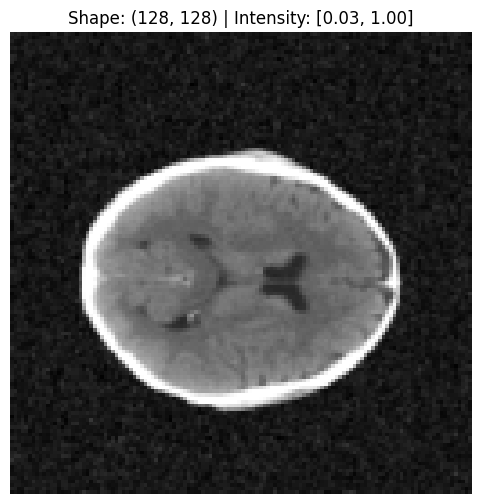

In [6]:
for data in train_dl:
    img = data['im'].to(cfg.device)
    
    # 1. Take the first sample and channel: (B, C, ...) -> (...)
    sample = img[0, 0].detach().cpu().numpy()
    
    # 2. Extract 2D slice if input is a 3D volume (H, W, D)
    if sample.ndim == 3:
        slice_2d = sample[:, :, sample.shape[-1] // 2]  # Middle axial slice
    else:
        slice_2d = sample  # Already 2D (H, W)
        
    # 3. Plot with Matplotlib
    plt.figure(figsize=(6, 6))
    plt.imshow(slice_2d, cmap="gray", origin="lower")
    plt.title(f"Shape: {slice_2d.shape} | Intensity: [{slice_2d.min():.2f}, {slice_2d.max():.2f}]")
    plt.axis("off")
    plt.show()
    
    break  # Stops after first batch; remove to inspect all batches

In [7]:
from vae import Model, Encoder, Decoder
import torch 
model_path = 'reports/ae_best.pth'

encoder = Encoder()
decoder = Decoder()
model = Model(Encoder = encoder, Decoder = decoder).to(cfg.device)
checkpoint = torch.load(model_path)
model.load_state_dict(checkpoint['encoder'])

You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.


KeyError: 'model'